### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [5]:
receita = {
    'Loja 1': loja['Preço'].sum(),
    'Loja 2': loja2['Preço'].sum(),
    'Loja 3': loja3['Preço'].sum(),
    'Loja 4': loja4['Preço'].sum()
}

for nome, valor in receita.items():
    print(f"{nome} - Faturamento: R$ {valor:,.2f}")


Loja 1 - Faturamento: R$ 1,534,509.12
Loja 2 - Faturamento: R$ 1,488,459.06
Loja 3 - Faturamento: R$ 1,464,025.03
Loja 4 - Faturamento: R$ 1,384,497.58


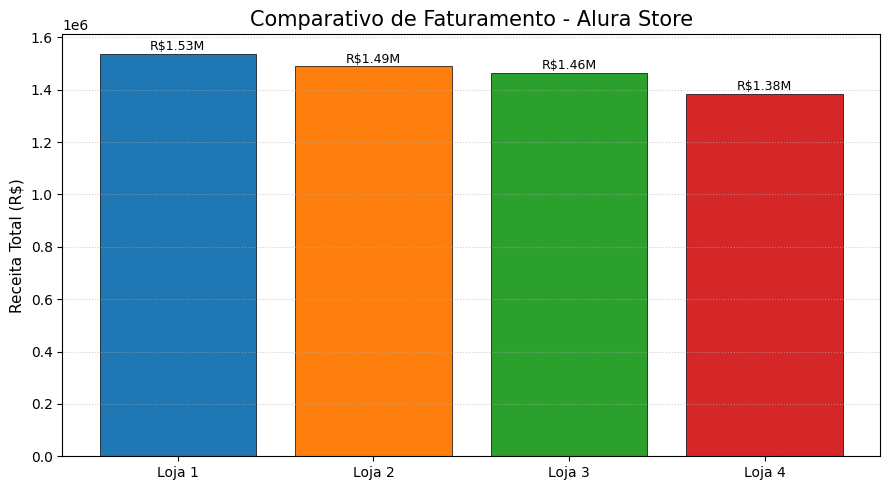

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

paleta = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
barras = ax.bar(receita.keys(), receita.values(), color=paleta, edgecolor='black', linewidth=0.5)

ax.set_title('Comparativo de Faturamento - Alura Store', fontsize=15)
ax.set_ylabel('Receita Total (R$)', fontsize=11)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)

for barra, val in zip(barras, receita.values()):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 15000,
            f'R${val/1e6:.2f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# 2. Vendas por Categoria

In [9]:
cat1 = loja['Categoria do Produto'].value_counts()
cat2 = loja2['Categoria do Produto'].value_counts()
cat3 = loja3['Categoria do Produto'].value_counts()
cat4 = loja4['Categoria do Produto'].value_counts()

print("Loja 1 - Categorias mais vendidas:")
print(cat1.head(5))
print()
print("Loja 2 - Categorias mais vendidas:")
print(cat2.head(5))
print()
print("Loja 3 - Categorias mais vendidas:")
print(cat3.head(5))
print()
print("Loja 4 - Categorias mais vendidas:")
print(cat4.head(5))

Loja 1 - Categorias mais vendidas:
Categoria do Produto
moveis              465
eletronicos         448
brinquedos          324
eletrodomesticos    312
esporte e lazer     284
Name: count, dtype: int64

Loja 2 - Categorias mais vendidas:
Categoria do Produto
moveis              442
eletronicos         422
brinquedos          313
eletrodomesticos    305
esporte e lazer     275
Name: count, dtype: int64

Loja 3 - Categorias mais vendidas:
Categoria do Produto
moveis              499
eletronicos         451
brinquedos          315
eletrodomesticos    278
esporte e lazer     277
Name: count, dtype: int64

Loja 4 - Categorias mais vendidas:
Categoria do Produto
moveis              480
eletronicos         451
brinquedos          338
esporte e lazer     277
eletrodomesticos    254
Name: count, dtype: int64


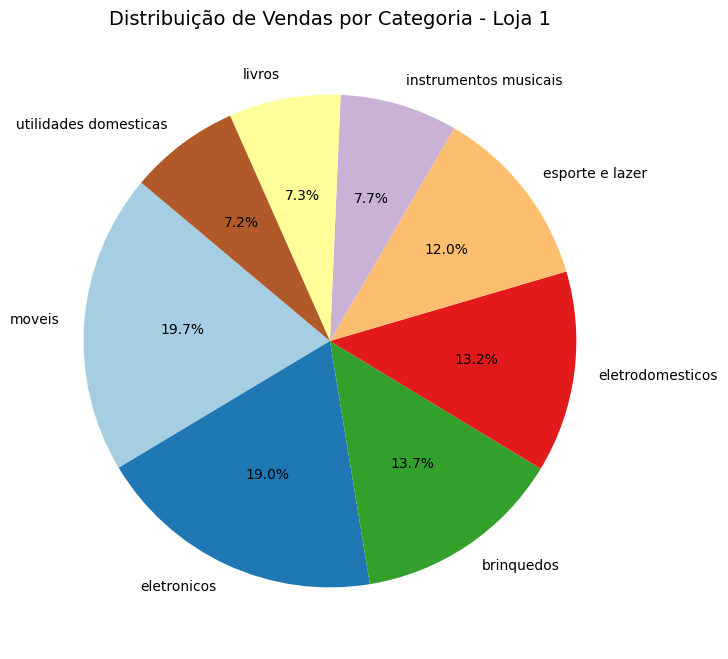

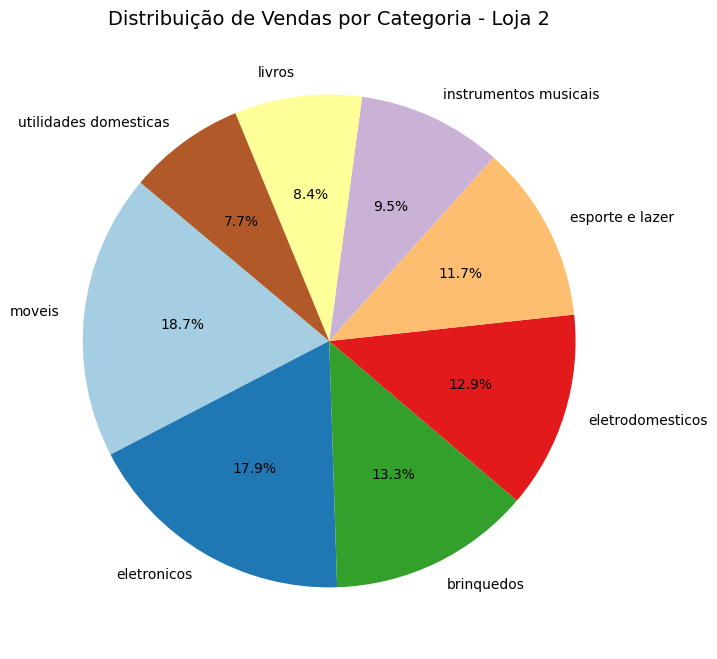

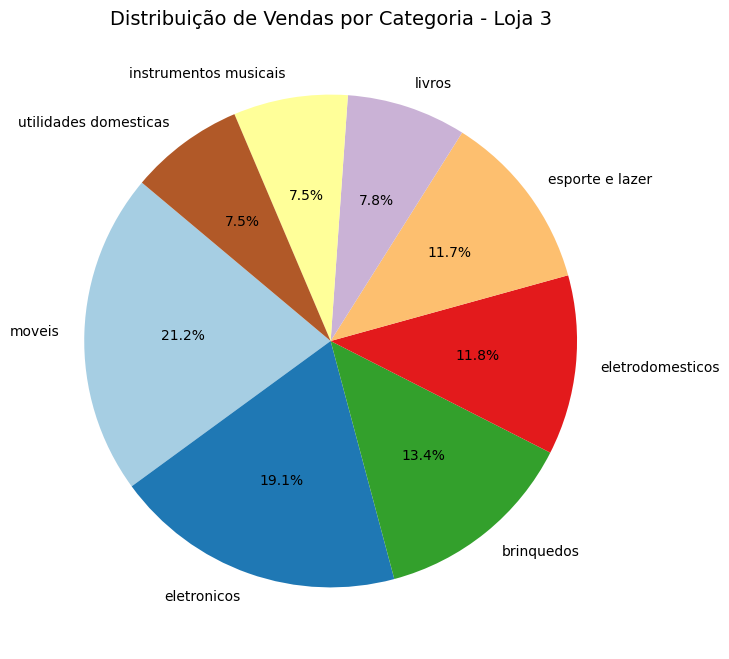

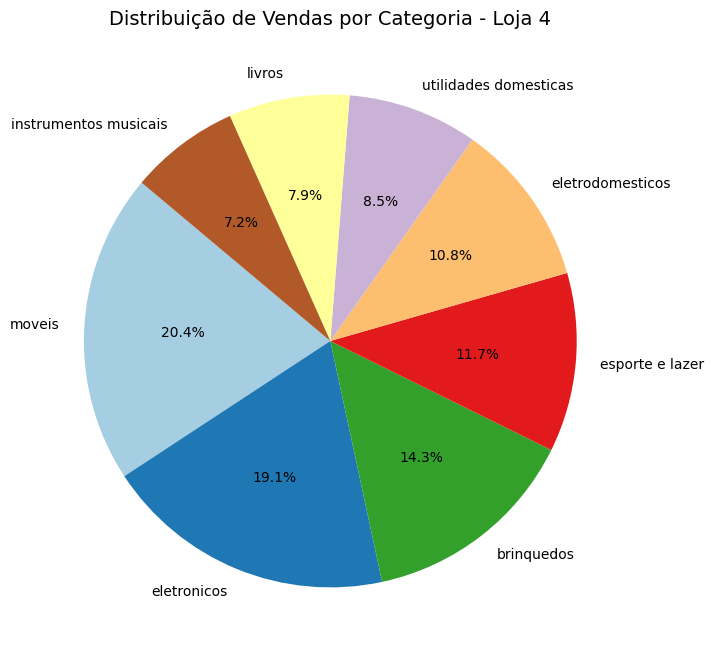

In [14]:
plt.figure(figsize=(8, 8))
cat1.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Paired')

plt.title('Distribuição de Vendas por Categoria - Loja 1', fontsize=14)
plt.ylabel('')
plt.show()

#2
plt.figure(figsize=(8, 8))
cat2.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Paired')

plt.title('Distribuição de Vendas por Categoria - Loja 2', fontsize=14)
plt.ylabel('')
plt.show()

#3
plt.figure(figsize=(8, 8))
cat3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Paired')

plt.title('Distribuição de Vendas por Categoria - Loja 3', fontsize=14)
plt.ylabel('')
plt.show()

#4
plt.figure(figsize=(8, 8))
cat4.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Paired')

plt.title('Distribuição de Vendas por Categoria - Loja 4', fontsize=14)
plt.ylabel('')
plt.show()

# 3. Média de Avaliação das Lojas


In [18]:
media1 = loja['Avaliação da compra'].mean()
media2 = loja2['Avaliação da compra'].mean()
media3 = loja3['Avaliação da compra'].mean()
media4 = loja4['Avaliação da compra'].mean()

medias_avaliacoes = [media1, media2, media3, media4]
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

print(f"Média Loja 1: {media1:.2f}")
print(f"Média Loja 2: {media2:.2f}")
print(f"Média Loja 3: {media3:.2f}")
print(f"Média Loja 4: {media4:.2f}")

Média Loja 1: 3.98
Média Loja 2: 4.04
Média Loja 3: 4.05
Média Loja 4: 4.00


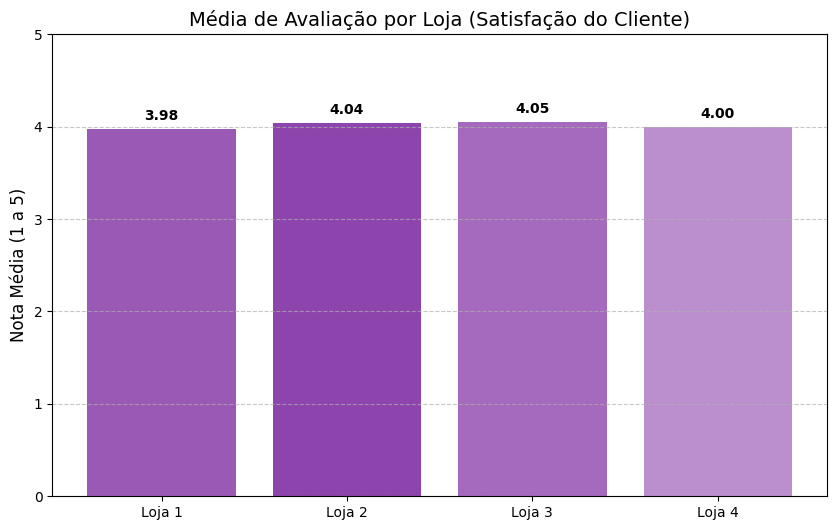

In [19]:
plt.figure(figsize=(10, 6))
cores_notas = ['#9b59b6', '#8e44ad', '#a569bd', '#bb8fce']
plt.bar(nomes_lojas, medias_avaliacoes, color=cores_notas)

plt.title('Média de Avaliação por Loja (Satisfação do Cliente)', fontsize=14)
plt.ylabel('Nota Média (1 a 5)', fontsize=12)
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(medias_avaliacoes):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


# 4. Produtos Mais e Menos Vendidos

In [22]:
vendas_loja1 = loja['Produto'].value_counts()
vendas_loja2 = loja2['Produto'].value_counts()
vendas_loja3 = loja3['Produto'].value_counts()
vendas_loja4 = loja4['Produto'].value_counts()

mais_vendidos_l1 = vendas_loja1.head(5)
menos_vendidos_l1 = vendas_loja1.tail(5)

mais_vendidos_l2 = vendas_loja2.head(5)
menos_vendidos_l2 = vendas_loja2.tail(5)

mais_vendidos_l3 = vendas_loja3.head(5)
menos_vendidos_l3 = vendas_loja3.tail(5)

mais_vendidos_l4 = vendas_loja4.head(5)
menos_vendidos_l4 = vendas_loja4.tail(5)

NameError: name 'lojas' is not defined

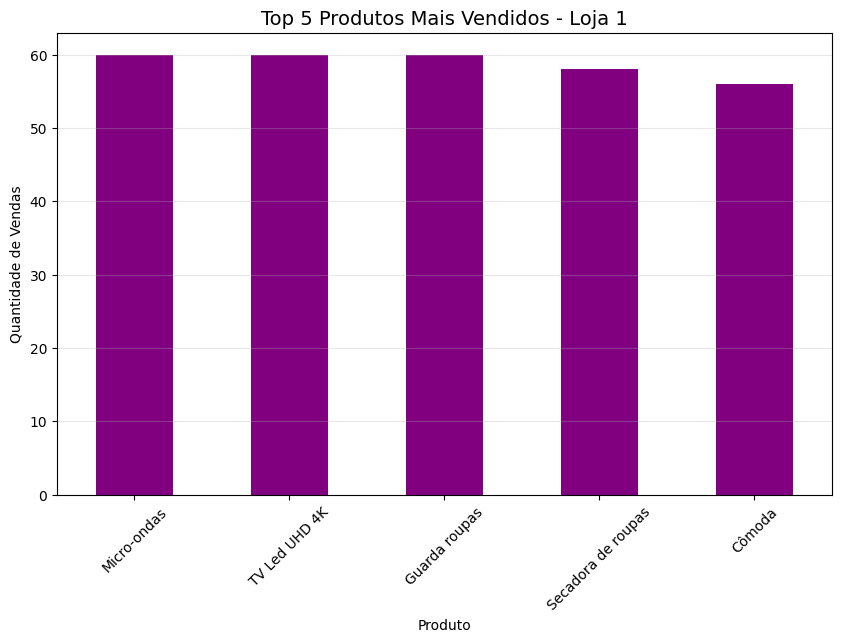

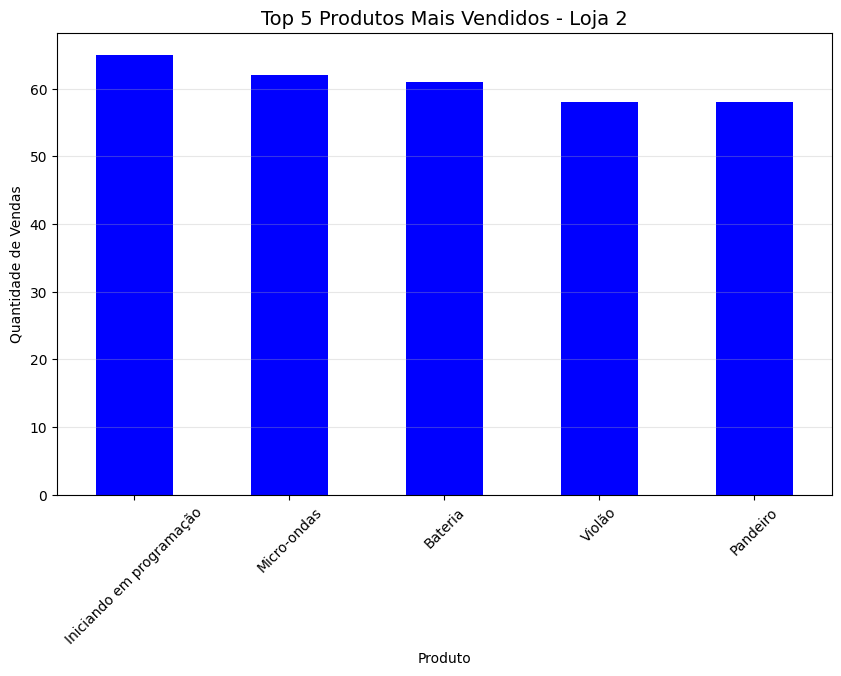

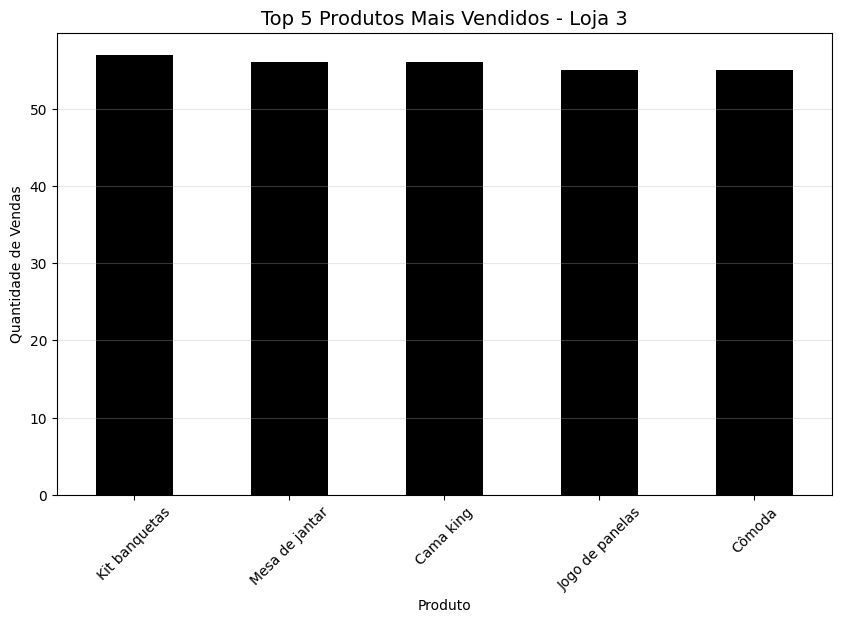

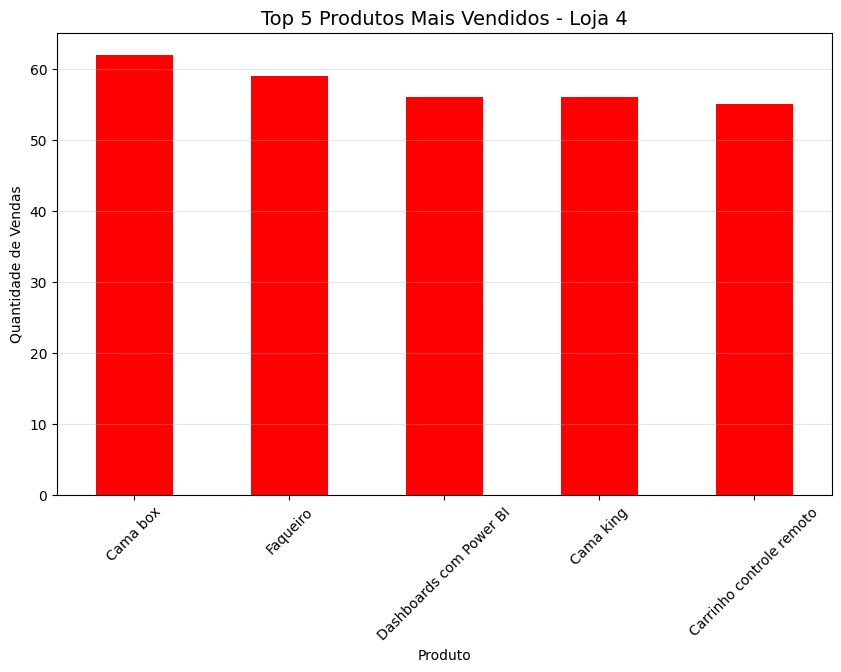

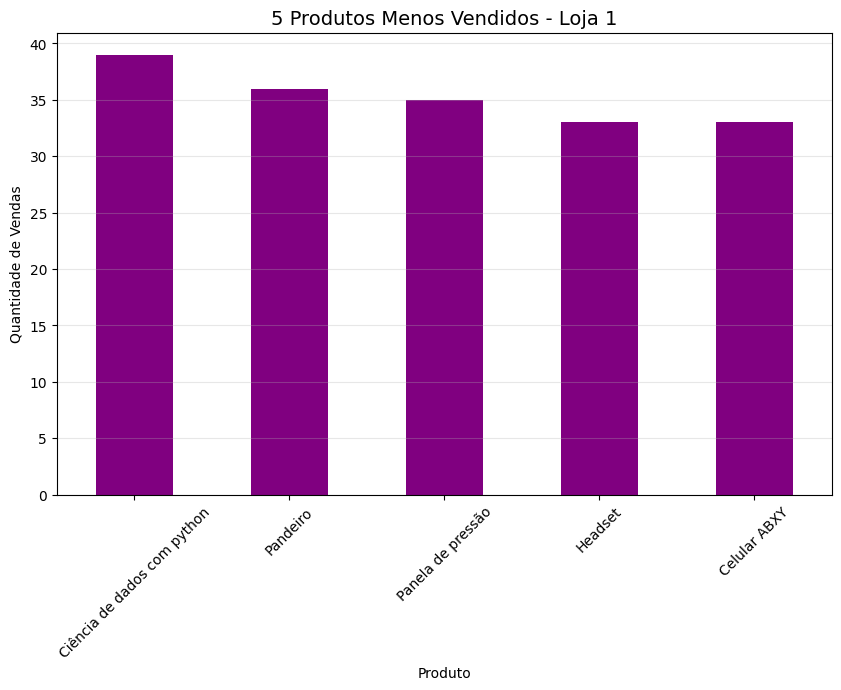

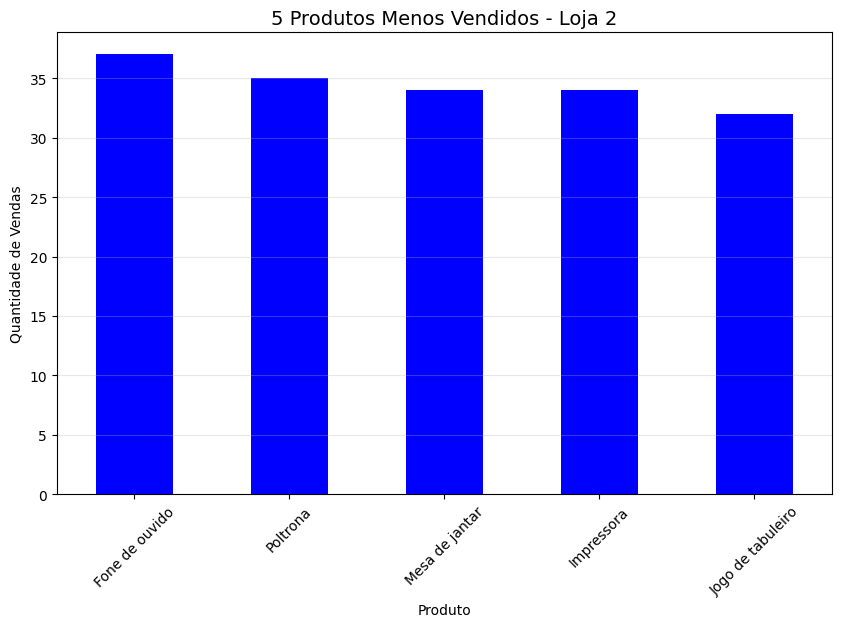

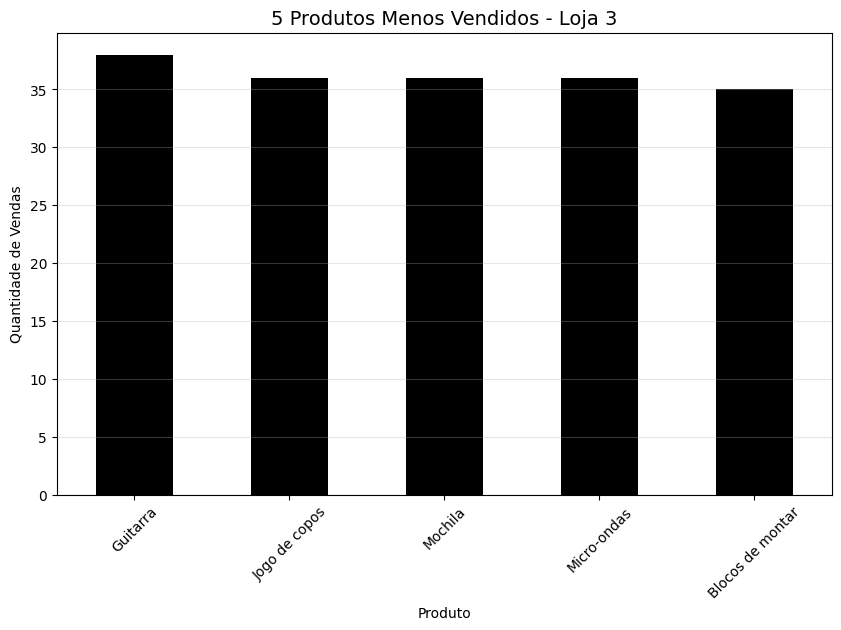

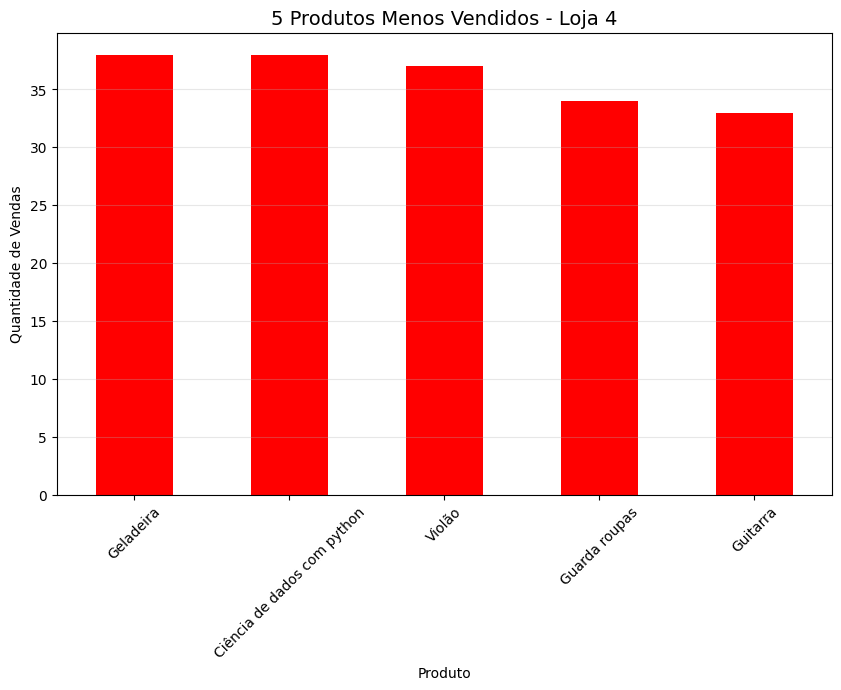

In [27]:
plt.figure(figsize=(10, 6))
mais_vendidos_l1.plot(kind='bar', color='purple')

plt.title('Top 5 Produtos Mais Vendidos - Loja 1', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

#2
plt.figure(figsize=(10, 6))
mais_vendidos_l2.plot(kind='bar', color='blue')

plt.title('Top 5 Produtos Mais Vendidos - Loja 2', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

#3
plt.figure(figsize=(10, 6))
mais_vendidos_l3.plot(kind='bar', color='black')

plt.title('Top 5 Produtos Mais Vendidos - Loja 3', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

#4
plt.figure(figsize=(10, 6))
mais_vendidos_l4.plot(kind='bar', color='red')

plt.title('Top 5 Produtos Mais Vendidos - Loja 4', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

plt.figure(figsize=(10, 6))
menos_vendidos_l1.plot(kind='bar', color='purple')

plt.title('5 Produtos Menos Vendidos - Loja 1', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

#2
plt.figure(figsize=(10, 6))
menos_vendidos_l2.plot(kind='bar', color='blue')

plt.title('5 Produtos Menos Vendidos - Loja 2', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

#3
plt.figure(figsize=(10, 6))
menos_vendidos_l3.plot(kind='bar', color='black')

plt.title('5 Produtos Menos Vendidos - Loja 3', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

#4
plt.figure(figsize=(10, 6))
menos_vendidos_l4.plot(kind='bar', color='red')

plt.title('5 Produtos Menos Vendidos - Loja 4', fontsize=14)
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

# 5. Frete Médio por Loja

In [28]:
frete_medio1 = loja['Frete'].mean()
frete_medio2 = loja2['Frete'].mean()
frete_medio3 = loja3['Frete'].mean()
frete_medio4 = loja4['Frete'].mean()

medias_frete = [frete_medio1, frete_medio2, frete_medio3, frete_medio4]
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

print(f"Frete Médio Loja 1: R$ {frete_medio1:.2f}")
print(f"Frete Médio Loja 2: R$ {frete_medio2:.2f}")
print(f"Frete Médio Loja 3: R$ {frete_medio3:.2f}")
print(f"Frete Médio Loja 4: R$ {frete_medio4:.2f}")

Frete Médio Loja 1: R$ 34.69
Frete Médio Loja 2: R$ 33.62
Frete Médio Loja 3: R$ 33.07
Frete Médio Loja 4: R$ 31.28


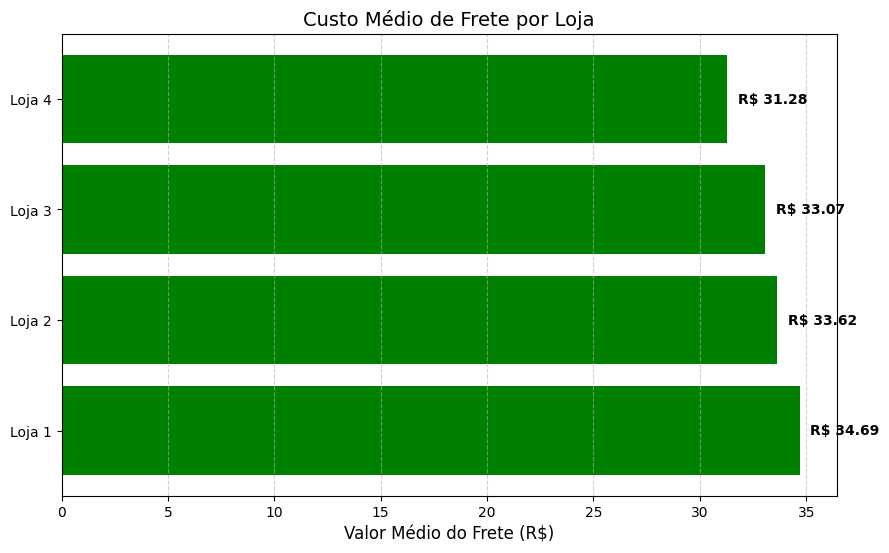

In [29]:
plt.figure(figsize=(10, 6))
plt.barh(nomes_lojas, medias_frete, color='green')

plt.title('Custo Médio de Frete por Loja', fontsize=14)
plt.xlabel('Valor Médio do Frete (R$)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(medias_frete):
    plt.text(v + 0.5, i, f"R$ {v:.2f}", va='center', fontweight='bold')

plt.show()